<a href="https://colab.research.google.com/github/aanjneyapankharaj/Final-project-sem-2/blob/main/Final_Project_sem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Name: Aanjneya Pankharaj , Aryan Jhamtani

## Prn: 25070123002 , 25070123005
##Branch: ENTC A-1
##Batch: 2025-29
##Title: Final Project "Retail sales data analysis"

# Retail Sales Dataset Analysis
### Adapted from Student Performance Analysis

# Step 1: Setup and File Upload


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/retail_sales_dataset.csv')
df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Date': 'date',
    'Customer ID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Product Category': 'product_category',
    'Quantity': 'quantity',
    'Price per Unit': 'price_per_unit',
    'Total Amount': 'total_amount'
}, inplace=True)
print('Dataset loaded successfully!')
print(df)


Dataset loaded successfully!
     transaction_id        date customer_id  gender  age product_category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     quantity  price_per_unit  total_amount  


# Step 2: Basic Dataset Inspection


In [ ]:
# Check overall shape, data types, and first few rows
print(f'Shape of dataset: {df.shape}\n')
print('--- First 5 Rows ---')
display(df.head())
print('\n--- Last 5 Rows ---')
display(df.tail())
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Dataset Info ---')
df.info()
print(f'\nColumns: {list(df.columns)}')


Shape of dataset: (1000, 9)

--- First 5 Rows ---


,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



--- Last 5 Rows ---


,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120



--- Data Types ---
transaction_id       int64
date                object
customer_id         object
gender              object
age                  int64
product_category    object
quantity             int64
price_per_unit       int64
total_amount         int64
dtype: object

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    1000 non-null   int64 
 1   date              1000 non-null   object
 2   customer_id       1000 non-null   object
 3   gender            1000 non-null   object
 4   age               1000 non-null   int64 
 5   product_category  1000 non-null   object
 6   quantity          1000 non-null   int64 
 7   price_per_unit    1000 non-null   int64 
 8   total_amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

Columns: ['transaction_id', 'date', 'c

# Step 3: Descriptive Statistics


In [ ]:
# Basic statistical measures for numerical columns
print('--- Numerical Summary ---')
display(df.describe())

print('\n--- Individual Statistics ---')
print(f"Mean Age: {df['age'].mean():.2f}")
print(f"Median Total Amount: {df['total_amount'].median()}")
print(f"Std Dev of Price per Unit: {df['price_per_unit'].std():.2f}")
print(f"Mean Quantity: {df['quantity'].mean():.2f}")



--- Numerical Summary ---


,transaction_id,age,quantity,price_per_unit,total_amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000



--- Individual Statistics ---
Mean Age: 41.39
Median Total Amount: 135.0
Std Dev of Price per Unit: 189.68
Mean Quantity: 2.51


# Step 4: Missing Value Analysis


In [ ]:
# Check for nulls
missing_data = df.isnull().sum()
print('--- Missing Values Count ---')
print(missing_data)

# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print('\n--- Missing Values Percentage ---')
print(missing_percent)

# If there were missing values, you could drop them using df.dropna(inplace=True)


--- Missing Values Count ---
transaction_id      0
date                0
customer_id         0
gender              0
age                 0
product_category    0
quantity            0
price_per_unit      0
total_amount        0
dtype: int64

--- Missing Values Percentage ---
transaction_id      0.0
date                0.0
customer_id         0.0
gender              0.0
age                 0.0
product_category    0.0
quantity            0.0
price_per_unit      0.0
total_amount        0.0
dtype: float64


# Step 5: Frequency Counts (value_counts)


In [ ]:
# Count occurrences of each distinct category
categorical_cols = ['gender', 'product_category']

for col in categorical_cols:
    print(f'\n--- Frequency for {col} ---')
    print(df[col].value_counts())

print('\n--- Frequency for quantity ---')
print(df['quantity'].value_counts().sort_index())



--- Frequency for gender ---
gender
Female    510
Male      490
Name: count, dtype: int64

--- Frequency for product_category ---
product_category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

--- Frequency for quantity ---
quantity
1    253
2    243
3    241
4    263
Name: count, dtype: int64


# Step 6: Unique Values (unique & nunique)


In [ ]:
# Number of unique values per column
print('--- Number of Unique Values per Column ---')
print(df.nunique())

print('\n--- Unique Values in Categorical Columns ---')
for col in categorical_cols:
    print(f'{col}: {df[col].unique()}')


--- Number of Unique Values per Column ---
transaction_id      1000
date                 345
customer_id         1000
gender                 2
age                   47
product_category       3
quantity               4
price_per_unit         5
total_amount          18
dtype: int64

--- Unique Values in Categorical Columns ---
gender: ['Male' 'Female']
product_category: ['Beauty' 'Clothing' 'Electronics']


# Step 7: Percentage Distribution


In [ ]:
for col in categorical_cols:
    print(f'\n--- Percentage Distribution for {col} ---')
    print(round(df[col].value_counts(normalize=True) * 100, 2).astype(str) + '%')



--- Percentage Distribution for gender ---
gender
Female    51.0%
Male      49.0%
Name: proportion, dtype: object

--- Percentage Distribution for product_category ---
product_category
Clothing       35.1%
Electronics    34.2%
Beauty         30.7%
Name: proportion, dtype: object


# Step 8: Filtering Data


In [ ]:
# 1. Transactions with Beauty products
beauty_sales = df[df['product_category'] == 'Beauty']

# 2. Male customers
male_customers = df[df['gender'] == 'Male']

# 3. High-value transactions (total_amount >= 500)
high_value = df[df['total_amount'] >= 500]

# 4. Low-value transactions (total_amount < 60)
low_value = df[df['total_amount'] < 60]

# 5. Female customers buying Electronics
female_electronics = df[(df['gender'] == 'Female') & (df['product_category'] == 'Electronics')]

print(f'Number of high-value transactions (>= 500): {len(high_value)}')
print(f'Number of low-value transactions (< 60): {len(low_value)}')
print(f'Female Electronics buyers: {len(female_electronics)}')


Number of high-value transactions (>= 500): 350
Number of low-value transactions (< 60): 217
Female Electronics buyers: 170


# Step 9: Cross Tabulation (pd.crosstab)


In [ ]:
print('--- Gender vs Product Category ---')
display(pd.crosstab(df['gender'], df['product_category']))

print('\n--- Quantity vs Product Category ---')
display(pd.crosstab(df['quantity'], df['product_category']))


--- Gender vs Product Category ---


product_category,Beauty,Clothing,Electronics
gender,,,
Female,166,174,170
Male,141,177,172



--- Quantity vs Product Category ---


product_category,Beauty,Clothing,Electronics
quantity,,,
1,74,88,91
2,75,80,88
3,85,86,70
4,73,97,93


# Step 10: Grouping Data (groupby)


In [ ]:
# Mean amounts grouped by gender
print('--- Mean Total Amount by Gender ---')
display(df.groupby('gender')[['total_amount', 'quantity', 'price_per_unit']].mean())

# Max/min total amount by product category
print('\n--- Max & Min Total Amount by Product Category ---')
display(df.groupby('product_category')['total_amount'].agg(['max', 'min', 'mean']))


--- Mean Total Amount by Gender ---


,total_amount,quantity,price_per_unit
gender,,,
Female,456.549020,2.545098,180.068627
Male,455.428571,2.481633,179.704082



--- Max & Min Total Amount by Product Category ---


,max,min,mean
product_category,,,
Beauty,2000,25,467.475570
Clothing,2000,25,443.247863
Electronics,2000,25,458.786550


# Step 11: Sorting


In [ ]:
# Sort by Total Amount descending (Top 5 transactions)
top_transactions = df.sort_values(by='total_amount', ascending=False).head()
display(top_transactions)

# Sort by Total Amount ascending (Bottom 5 transactions)
bottom_transactions = df.sort_values(by='total_amount', ascending=True).head()
display(bottom_transactions)

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
945,946,2023-05-08,CUST946,Male,62,Electronics,4,500,2000
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
576,577,2023-02-13,CUST577,Male,21,Beauty,4,500,2000
571,572,2023-04-20,CUST572,Male,31,Clothing,4,500,2000


,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
988,989,2023-12-28,CUST989,Female,44,Electronics,1,25,25
309,310,2023-10-12,CUST310,Female,28,Beauty,1,25,25
308,309,2023-12-23,CUST309,Female,26,Beauty,1,25,25
346,347,2023-08-03,CUST347,Male,42,Electronics,1,25,25
453,454,2023-02-22,CUST454,Female,46,Beauty,1,25,25


# Step 12: Adding Derived Columns


In [ ]:
# 1. Spending Category
def assign_spending_tier(amount):
    if amount >= 1000: return 'High Spender'
    elif amount >= 300: return 'Mid Spender'
    elif amount >= 100: return 'Low Spender'
    else: return 'Minimal'

df['spending_tier'] = df['total_amount'].apply(assign_spending_tier)

# 2. Revenue per item (price_per_unit * quantity validation)
df['calculated_total'] = df['price_per_unit'] * df['quantity']

# 3. Age group
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 100],
                          labels=['18-25', '26-35', '36-50', '51+'])

print('--- Data with New Derived Columns ---')
display(df[['age', 'age_group', 'total_amount', 'spending_tier', 'calculated_total']].head(10))


--- Data with New Derived Columns ---


,age,age_group,total_amount,spending_tier,calculated_total
0,34,26-35,150,Low Spender,150
1,26,26-35,1000,High Spender,1000
2,50,36-50,30,Minimal,30
3,37,36-50,500,Mid Spender,500
4,30,26-35,100,Low Spender,100
5,45,36-50,30,Minimal,30
6,46,36-50,50,Minimal,50
7,30,26-35,100,Low Spender,100
8,63,51+,600,Mid Spender,600
9,52,51+,200,Low Spender,200


# Step 13: Visualizations


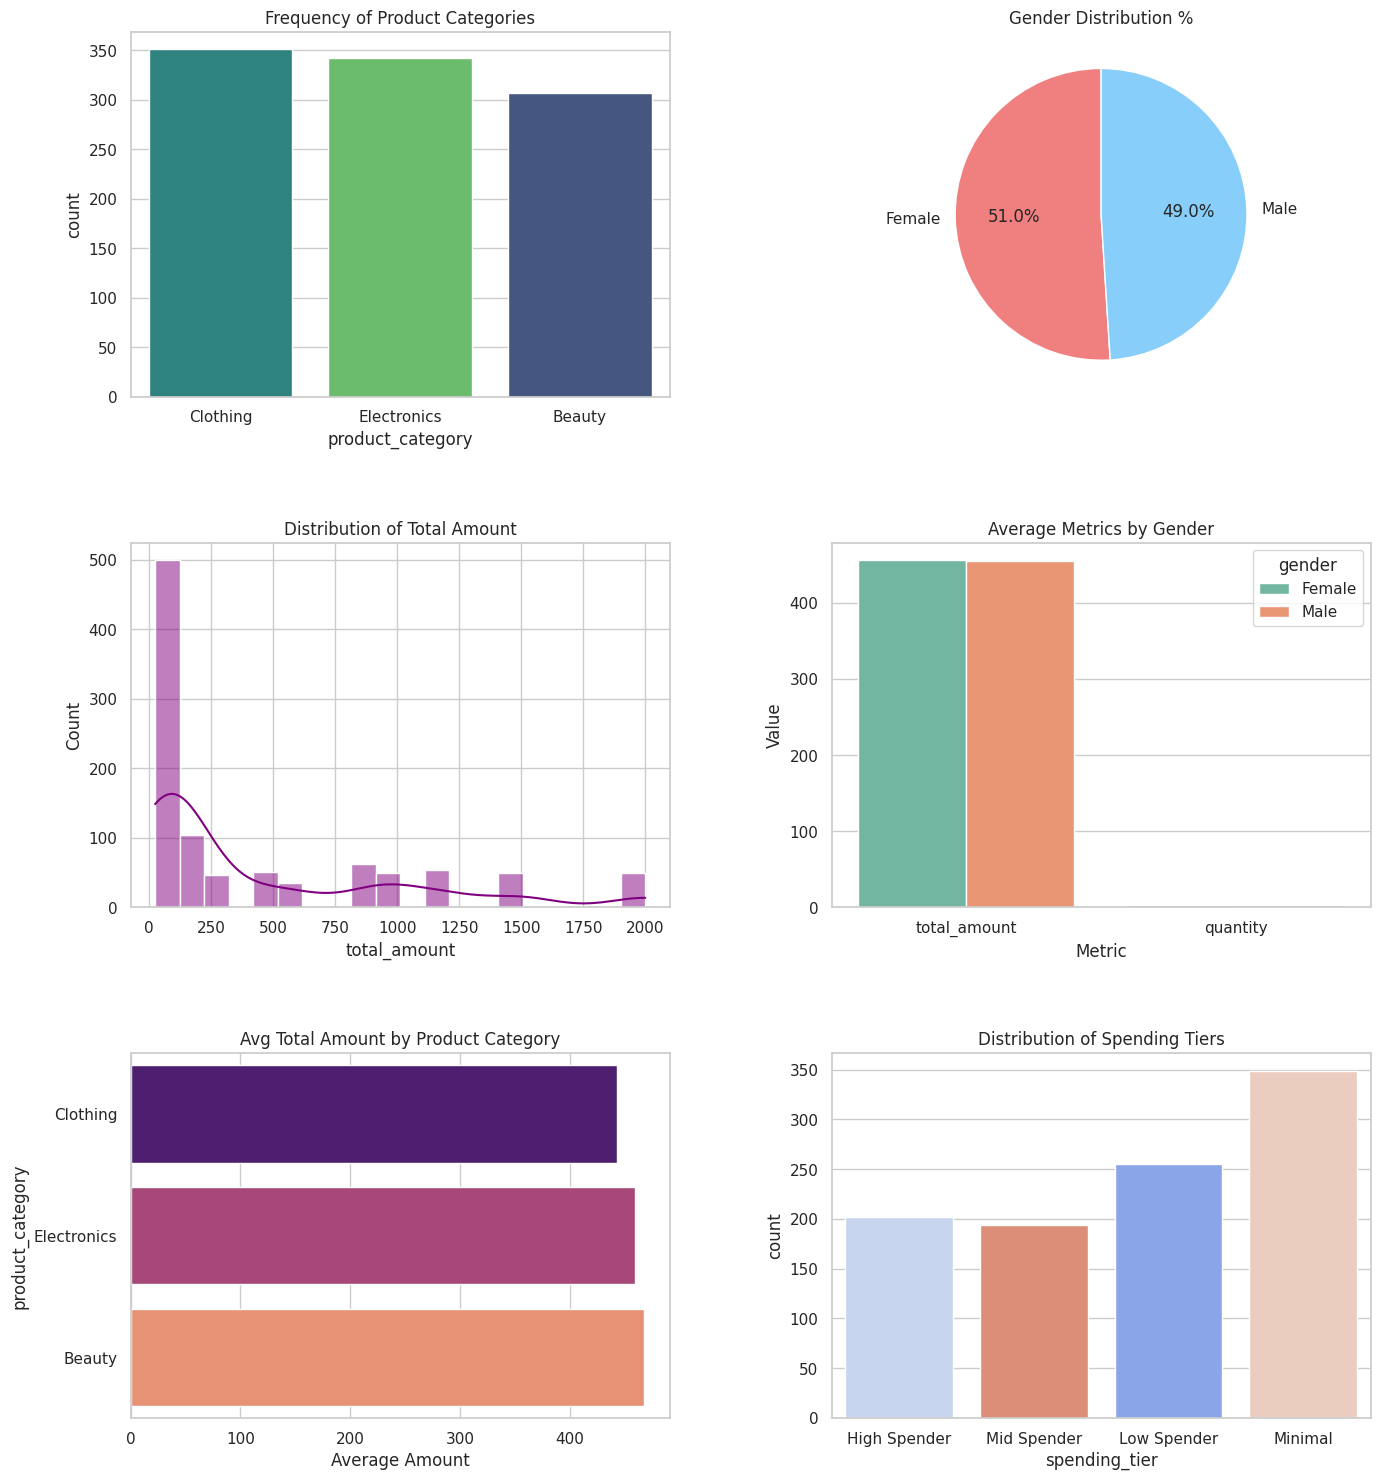

In [ ]:
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Bar Chart: Frequency of each product category
sns.countplot(data=df, x='product_category',
              order=df['product_category'].value_counts().index,
              ax=axes[0, 0], palette='viridis',
              hue='product_category', legend=False)
axes[0, 0].set_title('Frequency of Product Categories')

# 2. Pie Chart: Gender distribution
gender_counts = df['gender'].value_counts()
axes[0, 1].pie(gender_counts, labels=gender_counts.index,
               autopct='%1.1f%%',
               colors=['lightcoral', 'lightskyblue'],
               startangle=90)
axes[0, 1].set_title('Gender Distribution %')

# 3. Histogram: Distribution of Total Amount
sns.histplot(df['total_amount'], bins=20, kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Total Amount')

# 4. Grouped Bar: Avg total amount by gender
amt_gender = df.groupby('gender')[['total_amount', 'quantity']].mean().reset_index()
amt_melted = amt_gender.melt(id_vars='gender', var_name='Metric', value_name='Value')
sns.barplot(data=amt_melted, x='Metric', y='Value', hue='gender', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Average Metrics by Gender')

# 5. Horizontal Bar: Avg total amount by product category
avg_by_cat = df.groupby('product_category')['total_amount'].mean().sort_values()
sns.barplot(y=avg_by_cat.index, x=avg_by_cat.values, ax=axes[2, 0], palette='magma',
            hue=avg_by_cat.index, legend=False)
axes[2, 0].set_title('Avg Total Amount by Product Category')
axes[2, 0].set_xlabel('Average Amount')

# 6. Bar Chart: Distribution of Spending Tier
sns.countplot(data=df, x='spending_tier',
              order=['High Spender', 'Mid Spender', 'Low Spender', 'Minimal'],
              ax=axes[2, 1], palette='coolwarm',
              hue='spending_tier', legend=False)
axes[2, 1].set_title('Distribution of Spending Tiers')

plt.show()
